# Optimizing Redundant Paths Using Dijkstra's Algorithm for Enhancing Network Reliability

**MSc Computer Science dissertation notebook. Maryam Sirajo (BU/23C/PGS/9469), Baze University, Abuja.**

## What this notebook does, in plain words

A computer network is like a set of roads between cities. Data travels on these roads.
Sometimes a road (a cable, called a *link*) gets cut. In Nigeria this happens a lot:
road builders dig up fibre cables, and in March 2024 four undersea cables were cut at once.

**Dijkstra's algorithm** is a recipe that finds the cheapest (shortest) road from one city to another.
Normal routing uses Dijkstra **once** and keeps **one** road. When that road is cut, the network
has to stop, notice the cut, and run Dijkstra again. Data is lost while it waits.

This study uses Dijkstra **twice**, in advance:

1. **Pass 1:** Dijkstra finds the best road. This is the **primary path**.
2. **Pass 2:** we make every road used in Pass 1 very expensive, then run Dijkstra again.
   Dijkstra now avoids those roads, so it finds a second, separate road. This is the **backup path**.

When the primary road is cut, traffic jumps straight onto the backup road. No waiting for a new
calculation. Only one algorithm is used anywhere in this work: Dijkstra's algorithm.

## The six experiments

| No. | Question | What we measure |
|---|---|---|
| E1 | Is our own Dijkstra code correct? | Agreement with the NetworkX library on every pair |
| E2 | How often can Pass 2 find a fully separate backup, and how much longer is it? | Disjoint share, path stretch |
| E3 | When **one** link breaks, how many connections keep working at once? | Protected share |
| E4 | When **several** links break together, how many connections survive? | Survivability |
| E5 | How much computer time does each way of recovering need? | Milliseconds |
| E6 | In a long run with random cuts and repairs, how many packets are lost? | Packet delivery ratio, lost packets |

Run the cells from top to bottom (in Jupyter or Google Colab: *Runtime > Run all*).
Every number in the dissertation comes from this notebook.

## 0. Set-up
We load the tools we need. `networkx` stores the network, `numpy` and `pandas` handle numbers and
tables, `matplotlib` draws the charts, and `scipy` does the statistics test at the end.

In [1]:
import json, math, os, platform, random, statistics, time, itertools, heapq
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy
from scipy import stats

os.makedirs("figures/print", exist_ok=True)     # black-and-white charts for the dissertation
os.makedirs("figures/screen", exist_ok=True)    # coloured charts for slides and this notebook
os.makedirs("results", exist_ok=True)

print("Python    ", platform.python_version())
print("NetworkX  ", nx.__version__)
print("NumPy     ", np.__version__)
print("pandas    ", pd.__version__)
print("Matplotlib", matplotlib.__version__)
print("SciPy     ", scipy.__version__)
print("Machine   ", platform.processor() or platform.machine(), "|", os.cpu_count(), "CPU cores")

Python     3.13.16
NetworkX   3.6.1
NumPy      2.5.3
pandas     3.0.5
Matplotlib 3.11.2
SciPy      1.18.1
Machine    x86_64 | 2 CPU cores


### Chart style
Two styles: **print** uses only black and greys with different line patterns and markers, so the charts
still read when the dissertation is printed in black and white. **screen** uses blue for the plain
one-path Dijkstra and orange for the two-pass method.

In [2]:
STYLE = {
    "print":  {"single": "#7a7a7a", "redundant": "#000000", "reach": "#b5b5b5",
               "primary": "#000000", "backup": "#7a7a7a",
               "font": ["Times New Roman", "Liberation Serif", "DejaVu Serif"]},
    "screen": {"single": "#2a78d6", "redundant": "#eb6834", "reach": "#9a9a9a",
               "primary": "#222222", "backup": "#eb6834",
               "font": ["DejaVu Sans"]},
}

def use_style(kind):
    plt.rcParams.update({
        "font.family": "serif" if kind == "print" else "sans-serif",
        "font.serif": STYLE["print"]["font"], "font.sans-serif": STYLE["screen"]["font"],
        "font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10,
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.grid": True, "grid.color": "#dddddd", "grid.linewidth": 0.6,
        "legend.frameon": False, "figure.dpi": 110, "savefig.dpi": 300,
    })
    return STYLE[kind]

def save(fig, name):
    """Save the current chart into figures/print or figures/screen."""
    fig.savefig(f"figures/{CURRENT}/{name}.png", bbox_inches="tight")

## 1. The routing code (Dijkstra only)

### 1.1 Dijkstra's algorithm
Think of it like this. You stand in your home city. You write the cost to reach each neighbour on a list.
You always visit the **cheapest city on the list** next. When you visit a city, you check its neighbours:
"Is it cheaper to reach my neighbour through here?" If yes, you write the new, cheaper cost.
This checking step is called **relaxation**. You never visit a city twice. When there is nothing left on
the list, you know the cheapest cost to every city.

The "list" is a **priority queue** built with Python's `heapq` (a *binary heap*). It always hands back the
cheapest item quickly. A link cost must never be negative, or Dijkstra's answers can be wrong.

In [3]:
import heapq
import itertools
import math
import random
import time

import networkx as nx
import numpy as np
def dijkstra(graph, source, target=None, weight_fn=None):
    """Dijkstra's algorithm with a binary-heap priority queue.

    graph     : a NetworkX graph; every link carries a 'weight' (its cost).
    source    : the start node.
    target    : optional end node; the search stops as soon as it is settled.
    weight_fn : optional function (u, v, link_data) -> cost.
                Returning None means "this link cannot be used" (for example,
                because it has failed).

    Returns two dictionaries:
      dist[node] = cheapest known cost from the source to that node
      prev[node] = the node just before it on that cheapest route
    """
    if weight_fn is None:
        weight_fn = lambda u, v, data: data["weight"]

    dist = {source: 0.0}
    prev = {source: None}
    settled = set()                      # nodes whose cheapest cost is final
    tie = itertools.count()              # keeps the heap order stable on ties
    heap = [(0.0, next(tie), source)]    # (cost so far, tie-breaker, node)

    while heap:
        cost_u, _, u = heapq.heappop(heap)     # the cheapest unsettled node
        if u in settled:
            continue                           # an old, out-of-date heap entry
        settled.add(u)
        if u == target:
            break                              # we only needed this one node
        for v, data in graph[u].items():
            if v in settled:
                continue
            w = weight_fn(u, v, data)
            if w is None:
                continue                       # unusable link (e.g. failed)
            new_cost = cost_u + w
            if new_cost < dist.get(v, math.inf):   # the "relaxation" step
                dist[v] = new_cost
                prev[v] = u
                heapq.heappush(heap, (new_cost, next(tie), v))
    return dist, prev

### 1.2 Helpers
`build_path` walks backwards from the destination using the `prev` notes ("I came here from...").
`shortest_path` runs Dijkstra and returns the route and its cost. `path_links` lists the links a route uses.

In [4]:
def build_path(prev, source, target):
    """Walk backwards through prev[] to rebuild the route source -> target."""
    if target not in prev:
        return None                            # target was never reached
    path = [target]
    while path[-1] != source:
        path.append(prev[path[-1]])
    return path[::-1]


def shortest_path(graph, source, target, weight_fn=None):
    """Cheapest route and its cost, found with Dijkstra's algorithm."""
    dist, prev = dijkstra(graph, source, target, weight_fn)
    path = build_path(prev, source, target)
    return path, (dist[target] if path else math.inf)


def path_links(path):
    """The set of links a route uses. Each link is stored as frozenset({u, v})."""
    return {frozenset(pair) for pair in zip(path, path[1:])}


def path_cost(graph, path):
    """Total cost of a route, using the real (un-penalised) link weights."""
    return sum(graph[u][v]["weight"] for u, v in zip(path, path[1:]))

### 1.3 The two-pass procedure (primary path + backup path)
**Pass 1** is ordinary Dijkstra. **Pass 2** adds a big *penalty* to every link the primary path used and runs
Dijkstra again.

How big is the penalty? It is bigger than **all the link costs in the whole network added together**.
So using even one primary link in Pass 2 costs more than any complete route that avoids them. That means:
* if a fully separate route exists, Pass 2 will pick the cheapest one of those, and
* if no fully separate route exists (for example, a city with only one cable), Pass 2 shares as few links
  as it can.

We call this "two-pass Dijkstra". That name is just the label used in this study, not a term taken from
other papers.

In [5]:
def two_pass_redundant_paths(graph, source, target):
    """The two-pass Dijkstra procedure used in this study.

    Pass 1: run Dijkstra on the real link costs -> PRIMARY path.
    Pass 2: add a large penalty to every link the primary path uses, then run
            Dijkstra again -> BACKUP (redundant) path.

    The penalty is larger than the cost of every link in the network added
    together, so Pass 2 only reuses a primary link when there is no way
    around it. When a fully separate route exists, Pass 2 finds the cheapest
    such route. When it does not, Pass 2 shares as few links as possible.
    """
    primary, primary_cost = shortest_path(graph, source, target)
    if primary is None:
        return None
    primary_set = path_links(primary)
    penalty = graph.size(weight="weight") + 1.0

    def penalised_weight(u, v, data):
        extra = penalty if frozenset((u, v)) in primary_set else 0.0
        return data["weight"] + extra

    backup, _ = shortest_path(graph, source, target, weight_fn=penalised_weight)
    backup_set = path_links(backup)
    shared = primary_set & backup_set
    return {
        "primary": primary,
        "backup": backup,
        "primary_cost": primary_cost,
        "backup_cost": path_cost(graph, backup),
        "primary_links": primary_set,
        "backup_links": backup_set,
        "shared_links": shared,
        "disjoint": len(shared) == 0,
    }


def build_routing_table(graph):
    """Primary + backup path for every pair of nodes (computed in advance)."""
    table = {}
    for s, t in itertools.combinations(sorted(graph.nodes, key=str), 2):
        table[(s, t)] = two_pass_redundant_paths(graph, s, t)
    return table

## 2. The networks we test on

**Network 1: a hypothetical Nigerian backbone.** 20 cities joined by 31 links. The link cost is the straight-line
(great-circle) distance in kilometres, worked out with the haversine formula. This is *not* the real network of
any company. It is a made-up but realistic map, so the results are easy to picture.

**Network 2: synthetic scale-free networks** made with the Barabasi-Albert method: a few big "hub" nodes with
many links and many small nodes with few links. Each new node joins with `m = 2` links, so every node has at
least two links. Link costs are random whole numbers from 1 to 10.

In [6]:
# A HYPOTHETICAL backbone joining 20 Nigerian cities. It does not describe any
# operator's real network. City positions are approximate (latitude, longitude).
NIGERIA_CITIES = {
    "Lagos": (6.524, 3.379), "Ibadan": (7.378, 3.947), "Ilorin": (8.497, 4.543),
    "Benin City": (6.335, 5.604), "Lokoja": (7.802, 6.733), "Abuja": (9.077, 7.399),
    "Minna": (9.614, 6.557), "Kaduna": (10.511, 7.417), "Kano": (12.002, 8.592),
    "Katsina": (12.991, 7.602), "Sokoto": (13.006, 5.248), "Jos": (9.897, 8.858),
    "Bauchi": (10.316, 9.844), "Maiduguri": (11.831, 13.151), "Yola": (9.204, 12.495),
    "Makurdi": (7.732, 8.539), "Enugu": (6.458, 7.546), "Owerri": (5.484, 7.033),
    "Port Harcourt": (4.816, 7.050), "Calabar": (4.976, 8.342),
}

NIGERIA_LINKS = [
    ("Lagos", "Ibadan"), ("Lagos", "Benin City"), ("Ibadan", "Ilorin"),
    ("Ibadan", "Benin City"), ("Ilorin", "Minna"), ("Ilorin", "Lokoja"),
    ("Benin City", "Lokoja"), ("Benin City", "Enugu"), ("Benin City", "Port Harcourt"),
    ("Owerri", "Port Harcourt"), ("Owerri", "Enugu"), ("Port Harcourt", "Calabar"),
    ("Calabar", "Enugu"), ("Enugu", "Makurdi"), ("Lokoja", "Abuja"),
    ("Abuja", "Minna"), ("Abuja", "Kaduna"), ("Abuja", "Jos"), ("Abuja", "Makurdi"),
    ("Sokoto", "Katsina"), ("Sokoto", "Minna"), ("Kaduna", "Kano"),
    ("Kano", "Katsina"), ("Kaduna", "Jos"), ("Kano", "Bauchi"), ("Jos", "Bauchi"),
    ("Bauchi", "Maiduguri"), ("Maiduguri", "Yola"), ("Yola", "Bauchi"),
    ("Yola", "Makurdi"), ("Makurdi", "Jos"),
]


def haversine_km(a, b):
    """Great-circle distance in km between two (latitude, longitude) points."""
    lat1, lon1, lat2, lon2 = map(math.radians, (*a, *b))
    h = (math.sin((lat2 - lat1) / 2) ** 2
         + math.cos(lat1) * math.cos(lat2) * math.sin((lon2 - lon1) / 2) ** 2)
    return 2 * 6371.0 * math.asin(math.sqrt(h))


def nigeria_backbone():
    """Build the hypothetical 20-city backbone; link cost = distance in km."""
    g = nx.Graph(name="Hypothetical Nigerian backbone")
    for city, (lat, lon) in NIGERIA_CITIES.items():
        g.add_node(city, pos=(lon, lat))
    for a, b in NIGERIA_LINKS:
        km = haversine_km(NIGERIA_CITIES[a], NIGERIA_CITIES[b])
        g.add_edge(a, b, weight=round(km, 1))
    return g


def scale_free_network(n, m=2, seed=42):
    """Synthetic Barabasi-Albert network; link costs are whole numbers 1 to 10."""
    g = nx.barabasi_albert_graph(n, m, seed=seed)
    g.graph["name"] = f"Barabasi-Albert n={n}, m={m}"
    rng = random.Random(seed)
    for u, v in sorted(g.edges):
        g[u][v]["weight"] = rng.randint(1, 10)
    return g

In [7]:
NG = nigeria_backbone()
BA = scale_free_network(50, m=2, seed=42)

def describe(g):
    deg = [d for _, d in g.degree()]
    return {"network": g.graph["name"], "nodes": g.number_of_nodes(), "links": g.number_of_edges(),
            "min degree": min(deg), "mean degree": round(sum(deg) / len(deg), 2), "max degree": max(deg),
            "density": round(nx.density(g), 3), "bridges (single-link cuts)": len(list(nx.bridges(g)))}

topo_table = pd.DataFrame([describe(NG), describe(BA)])
topo_table

,network,nodes,links,min degree,mean degree,max degree,density,bridges (single-link cuts)
0,Hypothetical Nigerian backbone,20,31,2,3.10,5,0.163,0
1,"Barabasi-Albert n=50, m=2",50,96,2,3.84,24,0.078,0


In [8]:
links_table = pd.DataFrame([{"link": f"{u} - {v}", "distance_km": d["weight"]}
                            for u, v, d in NG.edges(data=True)]).sort_values("distance_km")
links_table.to_csv("results/nigeria_links.csv", index=False)
print("Shortest link:", links_table.iloc[0].to_dict())
print("Longest link: ", links_table.iloc[-1].to_dict())
print("Total length of all links (km):", round(links_table.distance_km.sum(), 1))

Shortest link: {'link': 'Owerri - Port Harcourt', 'distance_km': 74.3}
Longest link:  {'link': 'Yola - Makurdi', 'distance_km': 464.8}
Total length of all links (km): 6658.5


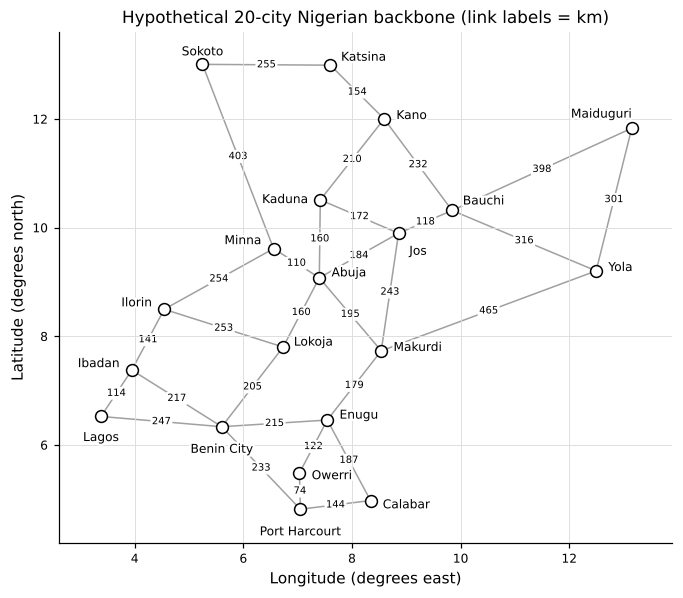

In [9]:
import matplotlib.patheffects as pe

# Where to put each city name (points right, points up, alignment) so names do not sit on lines.
LABEL_AT = {"Lagos": (0, -14, "center"), "Ibadan": (-8, 4, "right"), "Ilorin": (-8, 4, "right"),
            "Benin City": (0, -15, "center"), "Lokoja": (7, 3, "left"), "Abuja": (8, 3, "left"),
            "Minna": (-8, 5, "right"), "Kaduna": (-8, 0, "right"), "Kano": (8, 2, "left"),
            "Katsina": (7, 5, "left"), "Sokoto": (0, 8, "center"), "Jos": (7, -12, "left"),
            "Bauchi": (7, 6, "left"), "Maiduguri": (0, 9, "right"), "Yola": (8, 2, "left"),
            "Makurdi": (8, 2, "left"), "Enugu": (8, 3, "left"), "Owerri": (8, -2, "left"),
            "Port Harcourt": (0, -15, "center"), "Calabar": (8, -3, "left")}

def draw_nigeria(ax, g, colors, highlight=None, edge_km=False):
    pos = nx.get_node_attributes(g, "pos")
    nx.draw_networkx_edges(g, pos, ax=ax, edge_color="#a0a0a0", width=1.0)
    if highlight:
        for path, style, col, lab in highlight:
            edges = list(zip(path, path[1:]))
            nx.draw_networkx_edges(g, pos, edgelist=edges, ax=ax, edge_color=col, width=3.0,
                                   style=style, label=lab)
    if edge_km:
        nx.draw_networkx_edge_labels(g, pos, ax=ax, font_size=6.5, rotate=False,
                                     edge_labels={(u, v): f"{d['weight']:.0f}" for u, v, d in g.edges(data=True)},
                                     bbox={"boxstyle": "round,pad=0.15", "fc": "white", "ec": "none"})
    nx.draw_networkx_nodes(g, pos, ax=ax, node_size=60, node_color="white", edgecolors="black", linewidths=1.0)
    for city, (x, y) in pos.items():
        dx, dy, ha = LABEL_AT.get(city, (4, 4, "left"))
        ax.annotate(city, (x, y), xytext=(dx, dy), textcoords="offset points", fontsize=8, ha=ha,
                    va="center", path_effects=[pe.withStroke(linewidth=3, foreground="white")])
    ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True, labelsize=8)
    ax.set_xlabel("Longitude (degrees east)")
    ax.set_ylabel("Latitude (degrees north)")
    ax.set_xlim(2.6, 13.9)
    ax.set_ylim(4.2, 13.6)
    ax.set_aspect("equal")

for CURRENT in ("print", "screen"):
    c = use_style(CURRENT)
    fig, ax = plt.subplots(figsize=(7.2, 6.2))
    draw_nigeria(ax, NG, c, edge_km=True)
    ax.set_title("Hypothetical 20-city Nigerian backbone (link labels = km)")
    save(fig, "fig_topology_nigeria")
    if CURRENT == "print":
        plt.close(fig)
plt.show()

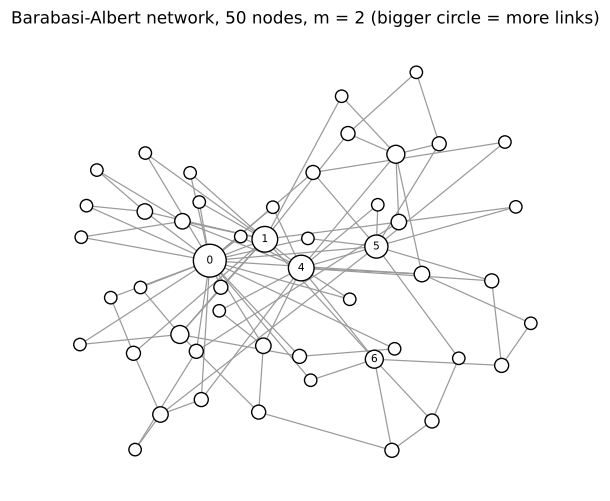

In [10]:
for CURRENT in ("print", "screen"):
    c = use_style(CURRENT)
    fig, ax = plt.subplots(figsize=(6.4, 5.4))
    pos = nx.spring_layout(BA, seed=7)
    sizes = [30 + 18 * d for _, d in BA.degree()]
    nx.draw_networkx_edges(BA, pos, ax=ax, edge_color="#9a9a9a", width=0.8)
    nx.draw_networkx_nodes(BA, pos, ax=ax, node_size=sizes, node_color="white", edgecolors="black", linewidths=0.9)
    hubs = sorted(BA.degree(), key=lambda x: -x[1])[:5]
    nx.draw_networkx_labels(BA, pos, labels={n: str(n) for n, _ in hubs}, ax=ax, font_size=7)
    ax.set_title("Barabasi-Albert network, 50 nodes, m = 2 (bigger circle = more links)")
    ax.axis("off")
    save(fig, "fig_topology_ba50")
    if CURRENT == "print":
        plt.close(fig)
plt.show()

## 3. A tiny worked example (Abuja districts)
Before the big networks, here is Dijkstra on six Abuja districts, so every step can be checked by hand.
Costs are in plain "units". We start at **Garki**.

Two small helper tools first: `dijkstra_trace` records every step of Dijkstra so we can print it as a table,
and `forwarding_entries` counts roughly how many switch rules the paths need (used later in E2).

In [11]:
def dijkstra_trace(graph, source):
    """Dijkstra step by step, for teaching: which node is settled at each step
    and the best cost known for every node right after that step."""
    dist = {n: math.inf for n in graph.nodes}
    dist[source] = 0.0
    prev = {source: None}
    settled, steps = [], []
    heap = [(0.0, str(source), source)]
    while heap:
        d, _, u = heapq.heappop(heap)
        if u in settled:
            continue
        settled.append(u)
        for v, data in graph[u].items():
            if v not in settled and d + data["weight"] < dist[v]:
                dist[v] = d + data["weight"]
                prev[v] = u
                heapq.heappush(heap, (dist[v], str(v), v))
        steps.append({"step": len(settled), "settled": u, "dist": dict(dist)})
    return steps


def forwarding_entries(table, redundant=True):
    """Rough count of switch rules needed: one rule per switch on each path
    (the destination switch needs none)."""
    total = 0
    for r in table.values():
        total += len(r["primary"]) - 1
        if redundant:
            total += len(r["backup"]) - 1
    return total

In [12]:
ABUJA = nx.Graph(name="Six Abuja districts (teaching example)")
for a, b, w in [("Garki", "Wuse", 4), ("Garki", "Asokoro", 2), ("Asokoro", "Wuse", 1), ("Wuse", "Jabi", 5),
                ("Asokoro", "Maitama", 7), ("Wuse", "Maitama", 3), ("Jabi", "Gwarinpa", 3),
                ("Maitama", "Gwarinpa", 6)]:
    ABUJA.add_edge(a, b, weight=w)

order = ["Garki", "Asokoro", "Wuse", "Maitama", "Jabi", "Gwarinpa"]
trace = dijkstra_trace(ABUJA, "Garki")
trace_rows = []
for s in trace:
    row = {"step": s["step"], "settled now": s["settled"]}
    row.update({n: ("inf" if s["dist"][n] == math.inf else int(s["dist"][n])) for n in order})
    trace_rows.append(row)
trace_table = pd.DataFrame(trace_rows)
trace_table.to_csv("results/abuja_trace.csv", index=False)
trace_table

,step,settled now,Garki,Asokoro,Wuse,Maitama,Jabi,Gwarinpa
0,1,Garki,0,2,4,inf,inf,inf
1,2,Asokoro,0,2,3,9,inf,inf
2,3,Wuse,0,2,3,6,8,inf
3,4,Maitama,0,2,3,6,8,12
4,5,Jabi,0,2,3,6,8,11
5,6,Gwarinpa,0,2,3,6,8,11


Primary: Garki -> Asokoro -> Wuse -> Jabi -> Gwarinpa | cost 11.0
Backup:  Garki -> Wuse -> Maitama -> Gwarinpa | cost 13
Fully separate? True


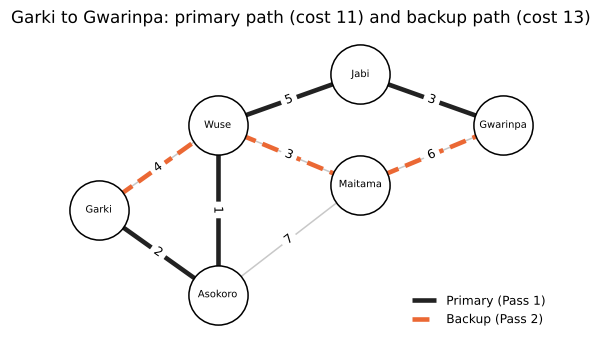

In [13]:
abuja_result = two_pass_redundant_paths(ABUJA, "Garki", "Gwarinpa")
print("Primary:", " -> ".join(abuja_result["primary"]), "| cost", abuja_result["primary_cost"])
print("Backup: ", " -> ".join(abuja_result["backup"]), "| cost", abuja_result["backup_cost"])
print("Fully separate?", abuja_result["disjoint"])

for CURRENT in ("print", "screen"):
    c = use_style(CURRENT)
    fig, ax = plt.subplots(figsize=(6.0, 3.6))
    apos = {"Garki": (0, 0), "Asokoro": (1, -1), "Wuse": (1, 1), "Maitama": (2.2, 0.3),
            "Jabi": (2.2, 1.6), "Gwarinpa": (3.4, 1.0)}
    nx.draw_networkx_edges(ABUJA, apos, ax=ax, edge_color="#c8c8c8", width=1.0)
    for path, style, col, lab in [(abuja_result["primary"], "solid", c["primary"], "Primary (Pass 1)"),
                                  (abuja_result["backup"], "dashed", c["backup"], "Backup (Pass 2)")]:
        nx.draw_networkx_edges(ABUJA, apos, edgelist=list(zip(path, path[1:])), ax=ax, width=3,
                               style=style, edge_color=col, label=lab)
    nx.draw_networkx_nodes(ABUJA, apos, ax=ax, node_size=1500, node_color="white", edgecolors="black")
    nx.draw_networkx_labels(ABUJA, apos, ax=ax, font_size=6.5)
    nx.draw_networkx_edge_labels(ABUJA, apos, ax=ax, font_size=8,
                                 edge_labels={(u, v): d["weight"] for u, v, d in ABUJA.edges(data=True)})
    ax.legend(loc="lower right", fontsize=8)
    ax.set_title("Garki to Gwarinpa: primary path (cost 11) and backup path (cost 13)")
    ax.set_xlim(-0.45, 3.85)
    ax.set_ylim(-1.5, 2.1)
    ax.axis("off")
    save(fig, "fig_abuja_example")
    if CURRENT == "print":
        plt.close(fig)
plt.show()

## 4. Experiment E1: is our Dijkstra correct?
We compare our hand-written Dijkstra with the Dijkstra inside the NetworkX library, for **every pair of nodes**.
If the costs match everywhere, our code is correct on these networks.

In [14]:
def correctness_check(g):
    pairs = list(itertools.combinations(g.nodes, 2))
    same = sum(abs(shortest_path(g, s, t)[1] - nx.dijkstra_path_length(g, s, t)) < 1e-9 for s, t in pairs)
    return {"network": g.graph["name"], "pairs checked": len(pairs), "costs that match": same,
            "agreement %": round(100 * same / len(pairs), 2)}

e1 = pd.DataFrame([correctness_check(NG), correctness_check(BA)] +
                  [correctness_check(scale_free_network(n, 2, seed=n)) for n in (100, 200)])
e1.to_csv("results/e1_correctness.csv", index=False)
e1

,network,pairs checked,costs that match,agreement %
0,Hypothetical Nigerian backbone,190,190,100.0
1,"Barabasi-Albert n=50, m=2",1225,1225,100.0
2,"Barabasi-Albert n=100, m=2",4950,4950,100.0
3,"Barabasi-Albert n=200, m=2",19900,19900,100.0


## 5. Experiment E2: primary and backup paths for every pair
We run the two-pass procedure for every pair of cities (190 pairs) and every pair of nodes in the 50-node network
(1,225 pairs). Then we ask:
* **Disjoint share:** for how many pairs is the backup *fully separate* (shares no link with the primary)?
* **Stretch:** how much longer is the backup? Stretch 1.5 means the backup costs 50% more than the primary.
* **Check:** for pairs where Pass 2 could not find a fully separate backup, did one exist at all?
  We check this with NetworkX's edge-disjoint path counter. This counter is only a checking tool; it is not
  used for routing.

In [15]:
t0 = time.perf_counter()
TABLE_NG = build_routing_table(NG)
t_ng = time.perf_counter() - t0
t0 = time.perf_counter()
TABLE_BA = build_routing_table(BA)
t_ba = time.perf_counter() - t0
print(f"Routing table built: Nigeria {len(TABLE_NG)} pairs in {t_ng*1000:.1f} ms; "
      f"BA-50 {len(TABLE_BA)} pairs in {t_ba*1000:.1f} ms")

def path_summary(g, table, label):
    rows = list(table.values())
    stretch = [r["backup_cost"] / r["primary_cost"] for r in rows]
    hop_p = [len(r["primary"]) - 1 for r in rows]
    hop_b = [len(r["backup"]) - 1 for r in rows]
    not_disjoint = [(k, r) for k, r in table.items() if not r["disjoint"]]
    missed = sum(len(list(nx.edge_disjoint_paths(g, *k))) >= 2 for k, _ in not_disjoint)
    return {"network": label, "pairs": len(rows),
            "fully separate backups": sum(r["disjoint"] for r in rows),
            "fully separate %": round(100 * sum(r["disjoint"] for r in rows) / len(rows), 2),
            "pairs where a separate pair existed but was missed": missed,
            "median stretch": round(statistics.median(stretch), 3),
            "mean stretch": round(statistics.mean(stretch), 3),
            "max stretch": round(max(stretch), 3),
            "mean primary hops": round(statistics.mean(hop_p), 2),
            "mean backup hops": round(statistics.mean(hop_b), 2)}

e2 = pd.DataFrame([path_summary(NG, TABLE_NG, "Nigeria-20"), path_summary(BA, TABLE_BA, "BA-50 (seed 42)")])
e2

Routing table built: Nigeria 190 pairs in 18.6 ms; BA-50 1225 pairs in 301.7 ms


,network,pairs,fully separate backups,fully separate %,pairs where a separate pair existed but was missed,median stretch,mean stretch,max stretch,mean primary hops,mean backup hops
0,Nigeria-20,190,188,98.95,2,1.523,1.792,7.395,2.98,4.34
1,BA-50 (seed 42),1225,1225,100.00,0,1.647,1.968,15.000,2.89,3.87


Ten more random 50-node networks, to see whether the BA-50 result was just luck with one network.

In [16]:
e2_seeds = []
for seed in range(1, 11):
    g = scale_free_network(50, 2, seed=seed)
    e2_seeds.append(path_summary(g, build_routing_table(g), f"BA-50 seed {seed}"))
e2_seeds = pd.DataFrame(e2_seeds)
print("Fully separate % across 10 networks: min", e2_seeds["fully separate %"].min(),
      "max", e2_seeds["fully separate %"].max())
print("Median stretch across 10 networks: mean", round(e2_seeds["median stretch"].mean(), 3),
      "sd", round(e2_seeds["median stretch"].std(), 3))
pd.concat([e2, e2_seeds]).to_csv("results/e2_paths.csv", index=False)
e2_seeds[["network", "fully separate %", "median stretch", "mean stretch", "max stretch"]]

Fully separate % across 10 networks: min 96.0 max 100.0
Median stretch across 10 networks: mean 1.577 sd 0.058


,network,fully separate %,median stretch,mean stretch,max stretch
0,BA-50 seed 1,100.0,1.600,2.075,18.0
1,BA-50 seed 2,96.0,1.562,1.864,22.0
2,BA-50 seed 3,100.0,1.643,1.959,21.0
3,BA-50 seed 4,96.0,1.556,1.818,21.0
4,BA-50 seed 5,100.0,1.529,1.827,18.0
5,BA-50 seed 6,100.0,1.692,1.974,26.0
6,BA-50 seed 7,100.0,1.600,1.962,21.0
7,BA-50 seed 8,100.0,1.533,1.860,16.0
8,BA-50 seed 9,100.0,1.556,1.964,16.0
9,BA-50 seed 10,100.0,1.500,1.879,22.0


### The pairs where Pass 2 was "trapped"
These are the Nigerian pairs whose backup still shares a link with the primary.

In [17]:
trap_rows = []
for (s, t), r in TABLE_NG.items():
    if not r["disjoint"]:
        exists = list(nx.edge_disjoint_paths(NG, s, t))
        trap_rows.append({"pair": f"{s} - {t}",
                          "primary": " > ".join(r["primary"]), "primary km": round(r["primary_cost"], 1),
                          "backup": " > ".join(r["backup"]), "backup km": round(r["backup_cost"], 1),
                          "shared link": ", ".join(" - ".join(sorted(x)) for x in r["shared_links"]),
                          "a separate pair that does exist": " | ".join(" > ".join(p) for p in exists[:2])})
traps = pd.DataFrame(trap_rows)
traps.to_csv("results/e2_traps.csv", index=False)
traps

,pair,primary,primary km,backup,backup km,shared link,a separate pair that does exist
0,Ibadan - Katsina,Ibadan > Ilorin > Minna > Abuja > Kaduna > Kan...,1027.1,Ibadan > Benin City > Lokoja > Abuja > Jos > B...,1269.0,Kano - Katsina,Ibadan > Ilorin > Minna > Sokoto > Katsina | I...
1,Ilorin - Katsina,Ilorin > Minna > Abuja > Kaduna > Kano > Katsina,886.4,Ilorin > Minna > Sokoto > Katsina,912.0,Ilorin - Minna,Ilorin > Minna > Sokoto > Katsina | Ilorin > L...


Lagos to Maiduguri
  primary: Lagos > Benin City > Lokoja > Abuja > Jos > Bauchi > Maiduguri (1311.6 km)
  backup:  Lagos > Ibadan > Benin City > Enugu > Makurdi > Yola > Maiduguri (1490.1 km)


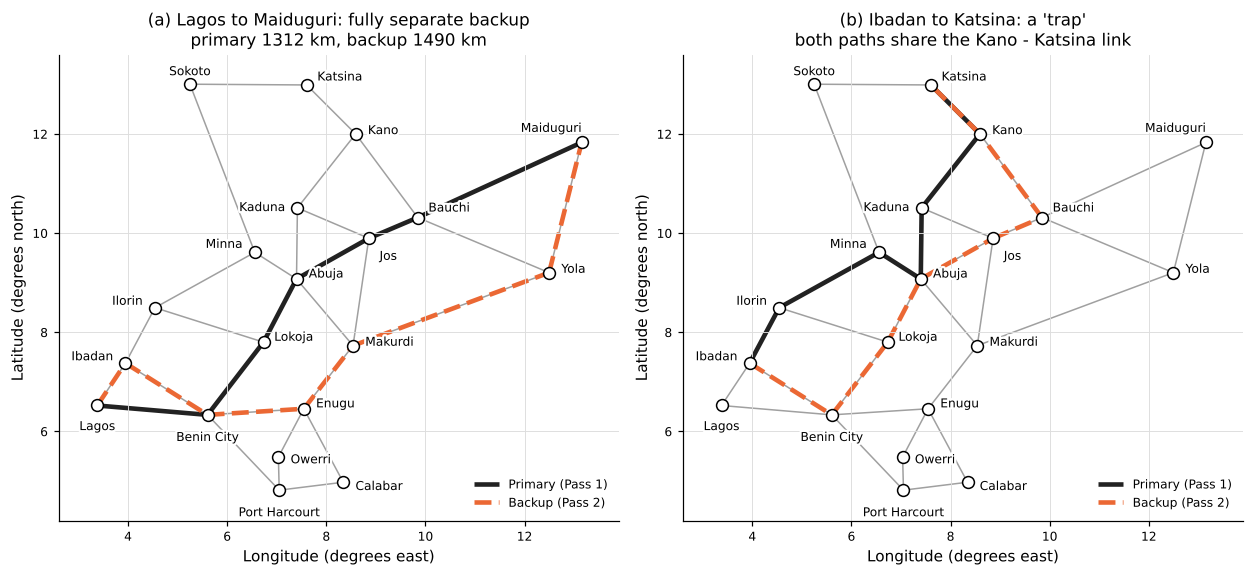

In [18]:
example = TABLE_NG[("Lagos", "Maiduguri")]
print("Lagos to Maiduguri")
print("  primary:", " > ".join(example["primary"]), f"({example['primary_cost']:.1f} km)")
print("  backup: ", " > ".join(example["backup"]), f"({example['backup_cost']:.1f} km)")

trap = TABLE_NG[("Ibadan", "Katsina")]
for CURRENT in ("print", "screen"):
    c = use_style(CURRENT)
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.2))
    draw_nigeria(axes[0], NG, c, [(example["primary"], "solid", c["primary"], "Primary (Pass 1)"),
                                  (example["backup"], "dashed", c["backup"], "Backup (Pass 2)")])
    axes[0].legend(loc="lower right", fontsize=8)
    axes[0].set_title(f"(a) Lagos to Maiduguri: fully separate backup\n"
                      f"primary {example['primary_cost']:.0f} km, backup {example['backup_cost']:.0f} km")
    draw_nigeria(axes[1], NG, c, [(trap["primary"], "solid", c["primary"], "Primary (Pass 1)"),
                                  (trap["backup"], "dashed", c["backup"], "Backup (Pass 2)")])
    axes[1].legend(loc="lower right", fontsize=8)
    axes[1].set_title("(b) Ibadan to Katsina: a 'trap'\nboth paths share the Kano - Katsina link")
    fig.tight_layout()
    save(fig, "fig_example_paths")
    if CURRENT == "print":
        plt.close(fig)
plt.show()

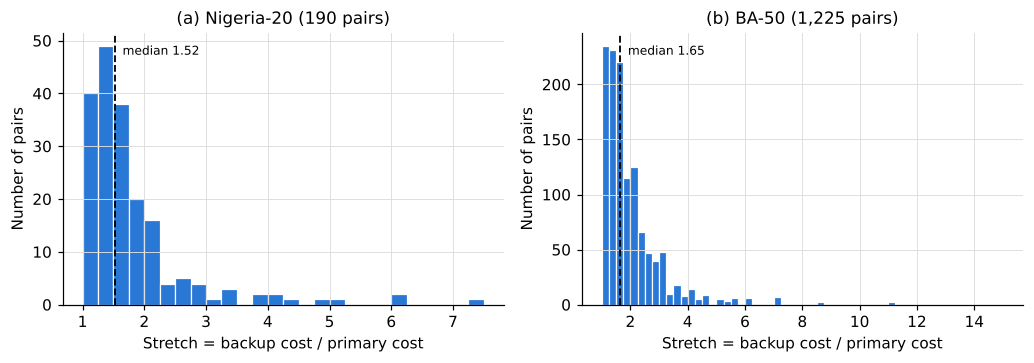

In [19]:
st_ng = [r["backup_cost"] / r["primary_cost"] for r in TABLE_NG.values()]
st_ba = [r["backup_cost"] / r["primary_cost"] for r in TABLE_BA.values()]
for CURRENT in ("print", "screen"):
    c = use_style(CURRENT)
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4), sharey=False)
    for ax, data, title in [(axes[0], st_ng, "(a) Nigeria-20 (190 pairs)"), (axes[1], st_ba, "(b) BA-50 (1,225 pairs)")]:
        ax.hist(data, bins=np.arange(1.0, max(data) + 0.25, 0.25), color=c["single"], edgecolor="white", linewidth=0.8)
        ax.axvline(statistics.median(data), color="black", linestyle="--", linewidth=1.2)
        ax.annotate(f"median {statistics.median(data):.2f}", (statistics.median(data), ax.get_ylim()[1] * 0.92),
                    xytext=(5, 0), textcoords="offset points", fontsize=8)
        ax.set_xlabel("Stretch = backup cost / primary cost")
        ax.set_ylabel("Number of pairs")
        ax.set_title(title)
    fig.tight_layout()
    save(fig, "fig_stretch")
    if CURRENT == "print":
        plt.close(fig)
plt.show()

### The cost of keeping backups: extra switch rules
A backup path only helps if the switches already know about it. Roughly, each switch on a path needs one rule.
Keeping backups therefore needs more rules (memory in the switches).

In [20]:
rules = pd.DataFrame([
    {"network": "Nigeria-20", "rules, primary only": forwarding_entries(TABLE_NG, False),
     "rules, primary + backup": forwarding_entries(TABLE_NG, True)},
    {"network": "BA-50", "rules, primary only": forwarding_entries(TABLE_BA, False),
     "rules, primary + backup": forwarding_entries(TABLE_BA, True)}])
rules["increase x"] = (rules["rules, primary + backup"] / rules["rules, primary only"]).round(2)
rules.to_csv("results/e2_rules.csv", index=False)
rules

,network,"rules, primary only","rules, primary + backup",increase x
0,Nigeria-20,567,1391,2.45
1,BA-50,3539,8284,2.34


## 6. Experiment E3: one link breaks
We break each link **on its own**, one at a time (31 links in the Nigerian network, 96 in BA-50).
For each break we count:
* **affected** connections: pairs whose primary path used the broken link;
* **protected** connections: affected pairs whose backup does *not* use the broken link, so they keep working
  at once, with no new calculation.

Plain one-path Dijkstra protects **none** of them instantly: every affected connection must wait for a re-run.

In [21]:
def single_failure_test(graph, table):
    """Break each link on its own, one at a time, and count what happens.

    affected  = pairs whose primary path used the broken link
    protected = affected pairs whose backup path does NOT use the broken link
                (they keep working at once, with no new calculation)
    """
    rows = []
    for u, v in graph.edges:
        broken = frozenset((u, v))
        affected = protected = 0
        for r in table.values():
            if broken in r["primary_links"]:
                affected += 1
                if broken not in r["backup_links"]:
                    protected += 1
        rows.append({"link": f"{u} - {v}", "affected": affected,
                     "protected": protected})
    return rows


def multi_failure_trial(graph, table, k, rng):
    """Break k random links at the same time and measure three things.

    single_path : share of pairs whose primary path still works
    redundant   : share of pairs whose primary OR backup path still works
    reachable   : share of pairs still joined by ANY route (the best that a
                  full re-run of Dijkstra could ever achieve)
    """
    edges = sorted(graph.edges, key=str)
    failed = {frozenset(e) for e in rng.sample(edges, k)}
    damaged = graph.copy()
    damaged.remove_edges_from(tuple(e) for e in failed)
    island = {}
    for i, part in enumerate(nx.connected_components(damaged)):
        for node in part:
            island[node] = i
    n = len(table)
    single = redundant = reachable = 0
    for (s, t), r in table.items():
        p_ok = not (r["primary_links"] & failed)
        b_ok = not (r["backup_links"] & failed)
        single += p_ok
        redundant += (p_ok or b_ok)
        reachable += island[s] == island[t]
    return single / n, redundant / n, reachable / n

In [22]:
e3_rows = []
for label, g, table in [("Nigeria-20", NG, TABLE_NG), ("BA-50", BA, TABLE_BA)]:
    df = pd.DataFrame(single_failure_test(g, table))
    df.insert(0, "network", label)
    e3_rows.append(df)
e3 = pd.concat(e3_rows)
e3.to_csv("results/e3_single_failure.csv", index=False)
e3_summary = e3.groupby("network").agg(links=("link", "count"), affected=("affected", "sum"),
                                       protected=("protected", "sum")).reset_index()
e3_summary["protected %"] = (100 * e3_summary.protected / e3_summary.affected).round(2)
e3_summary["unprotected"] = e3_summary.affected - e3_summary.protected
e3_summary

,network,links,affected,protected,protected %,unprotected
0,BA-50,96,3539,3539,100.00,0
1,Nigeria-20,31,567,565,99.65,2


In [23]:
print("Nigerian link failures that left some connection unprotected:")
print(e3[(e3.network == "Nigeria-20") & (e3.affected > e3.protected)].to_string(index=False))

Nigerian link failures that left some connection unprotected:
   network           link  affected  protected
Nigeria-20 Ilorin - Minna        22         21
Nigeria-20 Kano - Katsina        23         22


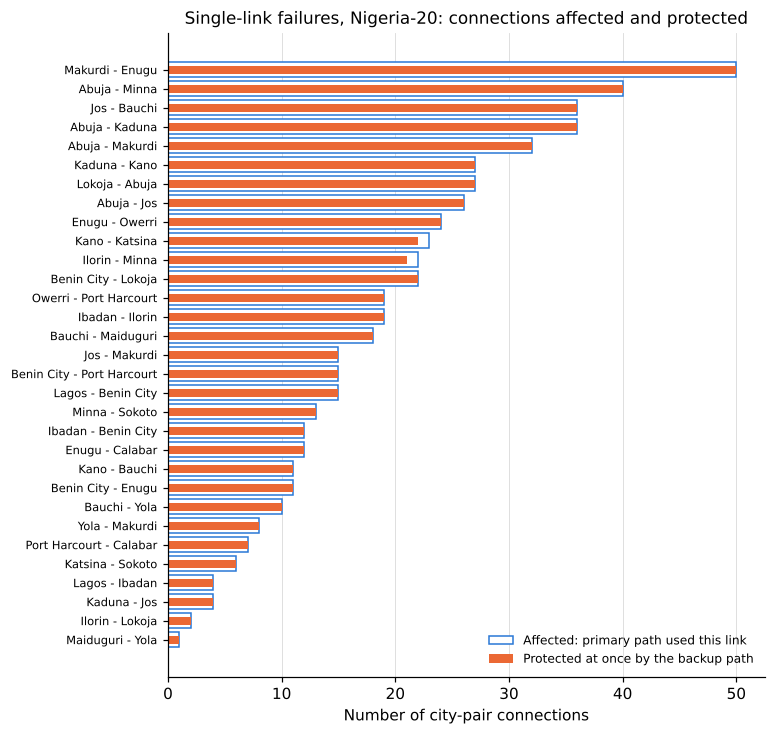

In [24]:
ng3 = e3[e3.network == "Nigeria-20"].sort_values("affected", ascending=True)
for CURRENT in ("print", "screen"):
    c = use_style(CURRENT)
    fig, ax = plt.subplots(figsize=(7.0, 7.6))
    y = np.arange(len(ng3))
    ax.barh(y, ng3.affected, color="white", edgecolor=c["single"], hatch="///" if CURRENT == "print" else None,
            label="Affected: primary path used this link")
    ax.barh(y, ng3.protected, color=c["redundant"], height=0.45, label="Protected at once by the backup path")
    ax.set_yticks(y, ng3.link, fontsize=7.5)
    ax.set_xlabel("Number of city-pair connections")
    ax.set_title("Single-link failures, Nigeria-20: connections affected and protected")
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(axis="y", visible=False)
    ax.set_axisbelow(True)
    save(fig, "fig_single_failure")
    if CURRENT == "print":
        plt.close(fig)
plt.show()

## 7. Experiment E4: several links break at the same time
Real networks sometimes lose more than one link at once (a road project can cut two cables; four undersea
cables were cut on the same day in 2024). We break **k** random links together, for k = 1 to 6, and repeat
this **2,000 times** for each k. For each trial we measure the share of connections that still work:
* **single path** (plain Dijkstra, before any re-run),
* **primary or backup** (two-pass Dijkstra, before any re-run),
* **reachable at all** (the best any method could do, even after a full re-run).

In [25]:
TRIALS = 2000
e4_rows, e4_raw = [], []
for label, g, table in [("Nigeria-20", NG, TABLE_NG), ("BA-50", BA, TABLE_BA)]:
    for k in range(1, 7):
        rng = random.Random(1000 + k)
        res = np.array([multi_failure_trial(g, table, k, rng) for _ in range(TRIALS)])
        for i, name in enumerate(["single", "redundant", "reachable"]):
            m = res[:, i].mean() * 100
            half = stats.t.ppf(0.975, TRIALS - 1) * res[:, i].std(ddof=1) / math.sqrt(TRIALS) * 100
            e4_rows.append({"network": label, "k": k, "method": name, "mean %": round(m, 2),
                            "95% CI half-width": round(half, 2)})
        w = stats.wilcoxon(res[:, 1], res[:, 0], zero_method="wilcox", alternative="greater")
        e4_raw.append({"network": label, "k": k, "wilcoxon_stat": float(w.statistic), "p_value": float(w.pvalue),
                       "trials_where_redundant_better": int((res[:, 1] > res[:, 0]).sum()),
                       "trials_tied": int((res[:, 1] == res[:, 0]).sum())})
e4 = pd.DataFrame(e4_rows)
e4_tests = pd.DataFrame(e4_raw)
e4.to_csv("results/e4_multi_failure.csv", index=False)
e4_tests.to_csv("results/e4_wilcoxon.csv", index=False)
e4.pivot_table(index=["network", "k"], columns="method", values="mean %")

method        reachable  redundant  single
network    k                              
BA-50      1     100.00     100.00   96.90
           2      99.97      99.75   94.14
           3      99.94      99.29   91.13
           4      99.87      98.60   88.53
           5      99.78      97.67   85.49
           6      99.60      96.56   82.86
Nigeria-20 1     100.00      99.96   90.10
           2      99.82      96.79   81.55
           3      99.39      91.95   73.68
           4      98.72      85.84   66.61
           5      97.30      79.29   59.96
           6      95.34      71.81   53.31

In [26]:
e4_tests

,network,k,wilcoxon_stat,p_value,trials_where_redundant_better,trials_tied
0,Nigeria-20,1,2001000.0,0.000000e+00,2000,0
1,Nigeria-20,2,1953276.0,0.000000e+00,1976,24
2,Nigeria-20,3,1987021.0,0.000000e+00,1993,7
3,Nigeria-20,4,1993006.0,0.000000e+00,1996,4
4,Nigeria-20,5,2001000.0,0.000000e+00,2000,0
5,Nigeria-20,6,2001000.0,0.000000e+00,2000,0
6,BA-50,1,1549680.0,1.639933e-289,1760,240
7,BA-50,2,1919820.0,0.000000e+00,1959,41
8,BA-50,3,1983036.0,0.000000e+00,1991,9
9,BA-50,4,1999000.0,0.000000e+00,1999,1


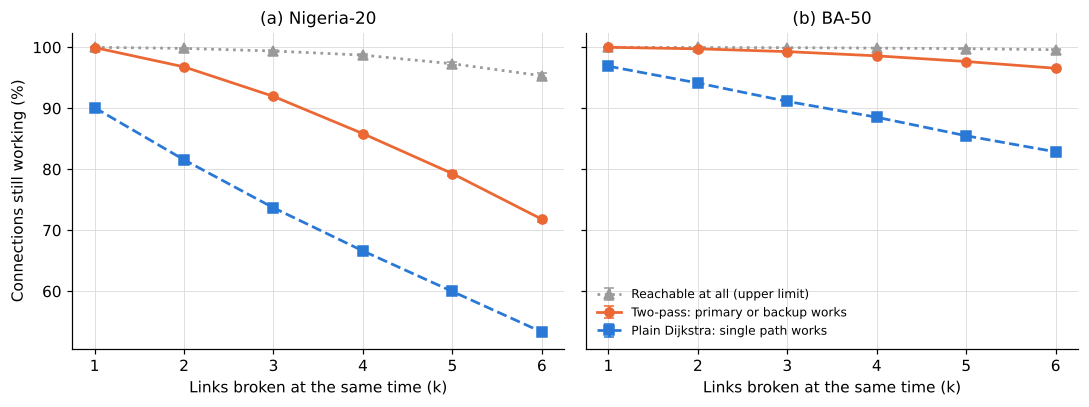

In [27]:
for CURRENT in ("print", "screen"):
    c = use_style(CURRENT)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
    for ax, label in zip(axes, ["Nigeria-20", "BA-50"]):
        d = e4[e4.network == label]
        for name, lab, mk, ls in [("reachable", "Reachable at all (upper limit)", "^", ":"),
                                  ("redundant", "Two-pass: primary or backup works", "o", "-"),
                                  ("single", "Plain Dijkstra: single path works", "s", "--")]:
            dd = d[d.method == name]
            ax.errorbar(dd.k, dd["mean %"], yerr=dd["95% CI half-width"], marker=mk, linestyle=ls,
                        color=c["reach"] if name == "reachable" else c[name], label=lab, markersize=6,
                        linewidth=1.8, capsize=3)
        ax.set_xlabel("Links broken at the same time (k)")
        ax.set_title(f"({'a' if label == 'Nigeria-20' else 'b'}) {label}")
    axes[0].set_ylabel("Connections still working (%)")
    axes[1].legend(loc="lower left", fontsize=8)
    fig.tight_layout()
    save(fig, "fig_multi_failure")
    if CURRENT == "print":
        plt.close(fig)
plt.show()

## 8. Experiment E5: how much computer time does recovery need?
For every single-link failure we time two things on this computer:
* **restoration** (plain Dijkstra): re-run Dijkstra for every affected connection on the damaged network;
* **protection** (two-pass): look up the stored backup for every affected connection.

We also time how long the two-pass procedure takes to prepare the backups *in advance*, and how the time per
pair grows as the network gets bigger (50 to 1,600 nodes). Times depend on the computer, so the exact numbers
matter less than the comparison.

In [28]:
def median_ms(fn, repeat=7):
    """Run fn() several times and return the median time in milliseconds."""
    times = []
    for _ in range(repeat):
        t0 = time.perf_counter()
        fn()
        times.append((time.perf_counter() - t0) * 1000.0)
    return float(np.median(times))


def recovery_compute_test(graph, table, repeat=7):
    """For every single-link failure, time the two ways of recovering.

    restoration : re-run Dijkstra (on the network without the broken link)
                  for every affected pair  -> what plain Dijkstra must do
    protection  : look up the stored backup for every affected pair
                  -> what the two-pass procedure does
    """
    rows = []
    for u, v in graph.edges:
        broken = frozenset((u, v))
        hit = [(s, t) for (s, t), r in table.items() if broken in r["primary_links"]]
        if not hit:
            continue
        skip = lambda a, b, d: None if frozenset((a, b)) == broken else d["weight"]
        restore = lambda: [shortest_path(graph, s, t, weight_fn=skip) for s, t in hit]
        protect = lambda: [table[p]["backup"] for p in hit
                           if broken not in table[p]["backup_links"]]
        rows.append({"link": f"{u} - {v}", "affected": len(hit),
                     "restoration_ms": median_ms(restore, repeat),
                     "protection_ms": median_ms(protect, repeat)})
    return rows

In [29]:
e5_rows = []
for label, g, table in [("Nigeria-20", NG, TABLE_NG), ("BA-50", BA, TABLE_BA)]:
    df = pd.DataFrame(recovery_compute_test(g, table, repeat=15))
    df.insert(0, "network", label)
    e5_rows.append(df)
e5 = pd.concat(e5_rows)
e5.to_csv("results/e5_recovery_compute.csv", index=False)
e5_summary = e5.groupby("network").agg(
    failures=("link", "count"),
    restoration_median_ms=("restoration_ms", "median"),
    restoration_max_ms=("restoration_ms", "max"),
    protection_median_ms=("protection_ms", "median"),
    protection_max_ms=("protection_ms", "max")).reset_index()
e5_summary["times faster (median)"] = (e5_summary.restoration_median_ms / e5_summary.protection_median_ms).round(1)
e5_summary.round(4)

,network,failures,restoration_median_ms,restoration_max_ms,protection_median_ms,protection_max_ms,times faster (median)
0,BA-50,84,4.0017,25.1635,0.0060,0.0416,666.4
1,Nigeria-20,31,0.5714,1.8870,0.0023,0.0076,250.8


In [30]:
scale_rows = []
for n in (50, 100, 200, 400, 800, 1600):
    g = scale_free_network(n, 2, seed=n)
    rng = random.Random(n)
    nodes = list(g.nodes)
    pairs = [tuple(rng.sample(nodes, 2)) for _ in range(150)]
    one = [median_ms(lambda: shortest_path(g, s, t), 5) for s, t in pairs]
    two = [median_ms(lambda: two_pass_redundant_paths(g, s, t), 5) for s, t in pairs]
    full = [median_ms(lambda: dijkstra(g, s), 5) for s, _ in pairs[:50]]
    scale_rows.append({"nodes": n, "links": g.number_of_edges(),
                       "one Dijkstra to a target (ms)": round(statistics.median(one), 4),
                       "two-pass per pair (ms)": round(statistics.median(two), 4),
                       "Dijkstra to all nodes (ms)": round(statistics.median(full), 4)})
e5_scale = pd.DataFrame(scale_rows)
e5_scale.to_csv("results/e5_scaling.csv", index=False)
e5_scale

,nodes,links,one Dijkstra to a target (ms),two-pass per pair (ms),Dijkstra to all nodes (ms)
0,50,96,0.0663,0.2360,0.1119
1,100,196,0.1373,0.4839,0.3823
2,200,396,0.3523,0.9701,0.4791
3,400,796,0.5580,1.9301,1.0121
4,800,1596,1.4049,4.2404,2.1803
5,1600,3196,2.6686,8.2986,4.4574


In [31]:
prep_rows = []
for n in (50, 100, 200):
    g = scale_free_network(n, 2, seed=n)
    t0 = time.perf_counter()
    build_routing_table(g)
    prep_rows.append({"nodes": n, "pairs": n * (n - 1) // 2,
                      "time to prepare all primary + backup paths (s)": round(time.perf_counter() - t0, 3)})
e5_prep = pd.DataFrame(prep_rows)
e5_prep.to_csv("results/e5_preparation.csv", index=False)
e5_prep

,nodes,pairs,time to prepare all primary + backup paths (s)
0,50,1225,0.284
1,100,4950,2.496
2,200,19900,18.272


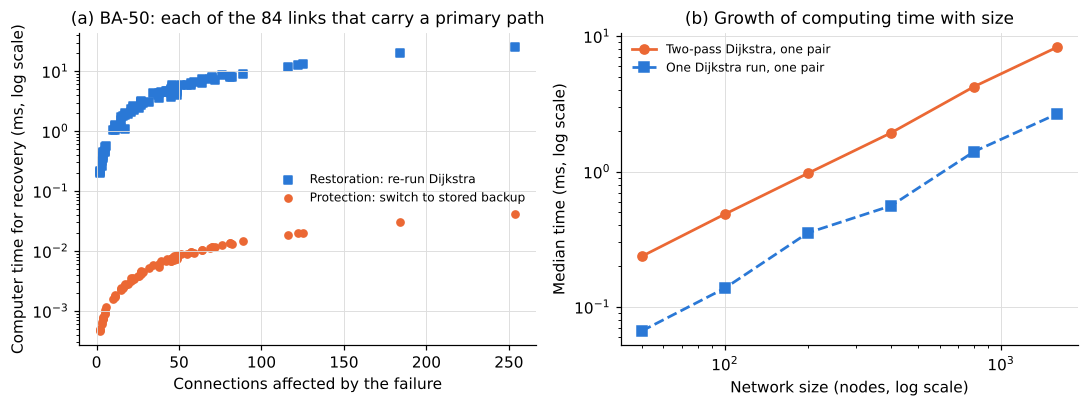

In [32]:
for CURRENT in ("print", "screen"):
    c = use_style(CURRENT)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
    d = e5[e5.network == "BA-50"]
    axes[0].scatter(d.affected, d.restoration_ms, marker="s", color=c["single"], s=22,
                    label="Restoration: re-run Dijkstra")
    axes[0].scatter(d.affected, d.protection_ms, marker="o", color=c["redundant"], s=22,
                    label="Protection: switch to stored backup")
    axes[0].set_yscale("log")
    axes[0].set_xlabel("Connections affected by the failure")
    axes[0].set_ylabel("Computer time for recovery (ms, log scale)")
    axes[0].set_title(f"(a) BA-50: each of the {len(d)} links that carry a primary path")
    axes[0].legend(fontsize=8, loc="center right")
    axes[1].plot(e5_scale.nodes, e5_scale["two-pass per pair (ms)"], marker="o", color=c["redundant"],
                 label="Two-pass Dijkstra, one pair", linewidth=1.8)
    axes[1].plot(e5_scale.nodes, e5_scale["one Dijkstra to a target (ms)"], marker="s", linestyle="--",
                 color=c["single"], label="One Dijkstra run, one pair", linewidth=1.8)
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")
    axes[1].set_xlabel("Network size (nodes, log scale)")
    axes[1].set_ylabel("Median time (ms, log scale)")
    axes[1].set_title("(b) Growth of computing time with size")
    axes[1].legend(fontsize=8)
    fig.tight_layout()
    save(fig, "fig_recovery_time")
    if CURRENT == "print":
        plt.close(fig)
plt.show()

## 9. Experiment E6: a long run with random cuts and repairs
Now we let time pass. Every one of the 190 city pairs sends **50 packets per second**, evenly spaced,
for **300 seconds**. During that time **20 random links are cut**, each at a random moment, and each is
repaired after a random **5 to 30 seconds**. Cuts can overlap, so sometimes two or three links are down together.

**Timing assumptions (taken from published surveys):**
* Spotting a failure takes **50 ms** (the BFD detection time reported by Alhiyari et al., 2025). We give this
  same 50 ms to *both* methods, which is fair to plain Dijkstra.
* Plain Dijkstra must then tell the controller, re-run Dijkstra and install new rules. Alhiyari et al. (2025)
  report that this kind of restoration needs **at least 100 ms** in total, and Ali et al. (2020) describe
  **200 to 300 ms** as realistic in large networks. Our main setting uses the most favourable value for plain
  Dijkstra (100 ms in total); a sensitivity test then tries 200, 300 and 500 ms.
* Two-pass Dijkstra switches to the stored backup straight after detection (50 ms), as long as the backup works.
  If the backup is also cut, it falls back to a full re-run, exactly like plain Dijkstra.

Some packets are lost no matter what: when two cuts isolate a city, no route exists at all. We measure this
"unavoidable" loss separately, so we can see the loss that routing can actually change.
Each setting is repeated **30 times** with different random cuts. Both methods face *exactly the same* cuts
and packets in each repeat, so the comparison is fair.

In [33]:
def make_failure_schedule(graph, duration_s, n_failures, repair_range_s, rng):
    """Pick random moments to cut random links, and a repair time for each cut.

    n_failures     : how many cuts happen during the run
    repair_range_s : (shortest, longest) repair time in seconds
    A link that is already cut is never cut again until it is repaired.
    """
    edges = sorted(graph.edges, key=str)
    cut_times = sorted(rng.uniform(0.0, duration_s) for _ in range(n_failures))
    down_until, events = {}, []
    for t in cut_times:
        choices = [frozenset(e) for e in edges if down_until.get(frozenset(e), -1.0) <= t]
        link = rng.choice(choices)
        repair_t = t + rng.uniform(*repair_range_s)
        down_until[link] = repair_t
        events.append((t, "fail", link))
        if repair_t < duration_s:
            events.append((repair_t, "repair", link))
    events.sort(key=lambda e: (e[0], e[1] == "fail"))   # repairs first on ties
    return events


def simulate_failures(graph, table, method, schedule, duration_s,
                      detect_s, install_s, compute_s, counts=None):
    """Event-driven simulation of link failures and repairs.

    method = "single"    : plain Dijkstra with one path. When the path breaks,
                           the flow is down for detect + compute + install time;
                           then Dijkstra is re-run on the links still working.
    method = "redundant" : two-pass Dijkstra. When the primary breaks and the
                           backup still works, the flow is down only for the
                           detection time (local switch-over). If both are
                           broken, it falls back to a full re-run, like "single".
    After a repair, every working flow moves back to its best path; this move
    is planned in advance, so no packets are lost during it.

    Returns {pair: [(down_start, down_end), ...]} in seconds.
    If a dictionary is passed as counts, it is filled with how many
    interruptions were handled by a fast switch-over and how many by a re-run.
    """
    if counts is None:
        counts = {}
    for key in ("switch", "rerun"):
        counts.setdefault(key, 0)
    failed = set()
    working = lambda a, b, d: None if frozenset((a, b)) in failed else d["weight"]
    restore_delay = detect_s + compute_s + install_s

    def best_path(pair):
        r = table[pair]
        if method == "redundant":
            if not (r["primary_links"] & failed):
                return r["primary"]
            if not (r["backup_links"] & failed):
                return r["backup"]
        p, _ = shortest_path(graph, pair[0], pair[1], weight_fn=working)
        return p

    current = {pair: table[pair]["primary"] for pair in table}
    down_since, waiting = {}, {}        # outage start; scheduled recovery kind
    pending, seq = [], itertools.count()
    outages = {pair: [] for pair in table}

    def schedule_recovery(pair, t, delay, kind):
        down_since.setdefault(pair, t)
        current[pair] = None
        waiting[pair] = kind
        heapq.heappush(pending, (t + delay, next(seq), pair, kind))

    def finish_recoveries(until):
        while pending and pending[0][0] <= until:
            t_rec, _, pair, kind = heapq.heappop(pending)
            if waiting.get(pair) != kind:
                continue
            del waiting[pair]
            if kind == "switch":
                if table[pair]["backup_links"] & failed:   # backup broke too
                    schedule_recovery(pair, t_rec, compute_s + install_s, "restore")
                    counts["switch"] -= 1
                    counts["rerun"] += 1
                    continue
                p = table[pair]["backup"]
            else:
                p = best_path(pair)
            if p is None:
                continue                  # no route at all: wait for a repair
            current[pair] = p
            outages[pair].append((down_since.pop(pair), t_rec))

    for t, kind, link in schedule:
        finish_recoveries(t)
        if kind == "fail":
            failed.add(link)
            for pair, p in current.items():
                if p is None or link not in path_links(p):
                    continue
                r = table[pair]
                if (method == "redundant" and p == r["primary"]
                        and not (r["backup_links"] & failed)):
                    schedule_recovery(pair, t, detect_s, "switch")
                    counts["switch"] += 1
                else:
                    schedule_recovery(pair, t, restore_delay, "restore")
                    counts["rerun"] += 1
        else:
            failed.discard(link)
            for pair in table:
                if pair in down_since:
                    if pair not in waiting:          # was cut off completely
                        schedule_recovery(pair, t, compute_s + install_s, "restore")
                else:
                    current[pair] = best_path(pair)
    finish_recoveries(duration_s)
    for pair, t0 in down_since.items():
        outages[pair].append((t0, duration_s))
    return outages


def count_lost_packets(outages, rate_pps, duration_s):
    """Every flow sends packets at a steady rate (like a ticking clock).

    A packet is lost if it is sent while its flow is down.
    Returns (packets sent, packets lost).
    """
    times = np.arange(0.0, duration_s, 1.0 / rate_pps)      # same clock for all
    sent = len(times) * len(outages)
    lost = 0
    for intervals in outages.values():
        for a, b in intervals:
            lost += int(np.searchsorted(times, b) - np.searchsorted(times, a))
    return sent, lost


def unavoidable_outages(graph, table, schedule, duration_s):
    """Periods when two cities are cut off from each other completely.

    During these periods NO routing method could deliver packets, so they set
    the floor for packet loss in the simulation.
    """
    failed = set()
    outages = {pair: [] for pair in table}
    times = [e[0] for e in schedule] + [duration_s]
    start = 0.0
    for i, (t, kind, link) in enumerate(schedule):
        failed.add(link) if kind == "fail" else failed.discard(link)
        end = times[i + 1]
        if not failed or end <= t:
            continue
        damaged = graph.copy()
        damaged.remove_edges_from(tuple(e) for e in failed)
        island = {n: k for k, part in enumerate(nx.connected_components(damaged))
                  for n in part}
        for (s, d) in table:
            if island[s] != island[d]:
                outages[(s, d)].append((t, end))
    return outages

In [34]:
DURATION_S, RATE_PPS, N_FAILURES, REPAIR_RANGE_S = 300.0, 50, 20, (5.0, 30.0)
DETECT_S = 0.050                                   # failure detection, both methods
COMPUTE_S = float(e5_summary.loc[e5_summary.network == "Nigeria-20", "restoration_median_ms"].iloc[0]) / 1000
RUNS = 30

def run_simulation(install_s, runs=RUNS):
    rows = []
    for run in range(1, runs + 1):
        sched = make_failure_schedule(NG, DURATION_S, N_FAILURES, REPAIR_RANGE_S, random.Random(run))
        floor_sent, floor_lost = count_lost_packets(unavoidable_outages(NG, TABLE_NG, sched, DURATION_S),
                                                    RATE_PPS, DURATION_S)
        row = {"run": run, "restoration_total_ms": round((DETECT_S + COMPUTE_S + install_s) * 1000, 1),
               "unavoidable_lost": floor_lost}
        for method in ("single", "redundant"):
            counts = {}
            out = simulate_failures(NG, TABLE_NG, method, sched, DURATION_S, DETECT_S, install_s, COMPUTE_S,
                                    counts=counts)
            sent, lost = count_lost_packets(out, RATE_PPS, DURATION_S)
            row[f"{method}_fast_switches"] = counts["switch"]
            row[f"{method}_reruns"] = counts["rerun"]
            row[f"{method}_sent"] = sent
            row[f"{method}_lost"] = lost
            row[f"{method}_pdr"] = 100 * (sent - lost) / sent
            row[f"{method}_avoidable_lost"] = lost - floor_lost
            row[f"{method}_interruptions"] = sum(len(v) for v in out.values())
        rows.append(row)
    return pd.DataFrame(rows)

sim_main = run_simulation(install_s=0.050)
sim_main.to_csv("results/e6_simulation_main.csv", index=False)
sim_main.head()

,run,restoration_total_ms,unavoidable_lost,single_fast_switches,single_reruns,single_sent,single_lost,single_pdr,single_avoidable_lost,single_interruptions,redundant_fast_switches,redundant_reruns,redundant_sent,redundant_lost,redundant_pdr,redundant_avoidable_lost,redundant_interruptions
0,1,100.6,0,0,469,2850000,2345,99.917719,2345,469,267,198,2850000,1665,99.941579,1665,465
1,2,100.6,0,0,311,2850000,1565,99.945088,1565,311,229,89,2850000,987,99.965368,987,318
2,3,100.6,5548,0,331,2850000,7146,99.749263,1598,331,275,57,2850000,6490,99.772281,942,332
3,4,100.6,3173,0,339,2850000,4792,99.831860,1619,339,214,128,2850000,4287,99.849579,1114,342
4,5,100.6,0,0,339,2850000,1695,99.940526,1695,339,250,95,2850000,1129,99.960386,1129,345


In [35]:
def mean_ci(x):
    x = np.asarray(x, dtype=float)
    half = stats.t.ppf(0.975, len(x) - 1) * x.std(ddof=1) / math.sqrt(len(x))
    return x.mean(), half

summary = {}
for col in ["single_pdr", "redundant_pdr", "single_avoidable_lost", "redundant_avoidable_lost",
            "unavoidable_lost", "single_interruptions", "redundant_interruptions",
            "redundant_fast_switches", "redundant_reruns", "single_reruns"]:
    m, h = mean_ci(sim_main[col])
    summary[col] = (round(m, 4), round(h, 4))
w_loss = stats.wilcoxon(sim_main.redundant_avoidable_lost, sim_main.single_avoidable_lost, alternative="less")
w_pdr = stats.wilcoxon(sim_main.redundant_pdr, sim_main.single_pdr, alternative="greater")
reduction = 100 * (1 - sim_main.redundant_avoidable_lost.sum() / sim_main.single_avoidable_lost.sum())
print("Mean (95% CI half-width) over 30 runs, restoration total =", sim_main.restoration_total_ms.iloc[0], "ms")
for k, (m, h) in summary.items():
    print(f"  {k:28s} {m:>14,.4f}  +/- {h:,.4f}")
print(f"Avoidable packet loss cut by {reduction:.1f}%")
print(f"Wilcoxon (avoidable loss, redundant < single): W = {w_loss.statistic}, p = {w_loss.pvalue:.3g}")
print(f"Wilcoxon (PDR, redundant > single):            W = {w_pdr.statistic}, p = {w_pdr.pvalue:.3g}")
share_fast = 100 * sim_main.redundant_fast_switches.sum() / (sim_main.redundant_fast_switches.sum()
                                                             + sim_main.redundant_reruns.sum())
print(f"Two-pass: {share_fast:.1f}% of path breaks were handled by a fast switch to the backup;"
      f" the rest needed a re-run because the backup was broken too")
print("Runs where two-pass lost fewer avoidable packets:",
      int((sim_main.redundant_avoidable_lost < sim_main.single_avoidable_lost).sum()), "of", RUNS)

Mean (95% CI half-width) over 30 runs, restoration total = 100.6 ms
  single_pdr                          99.8030  +/- 0.0783
  redundant_pdr                       99.8258  +/- 0.0779
  single_avoidable_lost            1,882.6333  +/- 128.0349
  redundant_avoidable_lost         1,233.2333  +/- 99.0875
  unavoidable_lost                 3,731.6333  +/- 2,213.7832
  single_interruptions               380.8333  +/- 26.0016
  redundant_interruptions            382.4333  +/- 24.7805
  redundant_fast_switches            261.9000  +/- 14.8463
  redundant_reruns                   120.5333  +/- 16.9237
  single_reruns                      380.8333  +/- 26.0016
Avoidable packet loss cut by 34.5%
Wilcoxon (avoidable loss, redundant < single): W = 0.0, p = 9.31e-10
Wilcoxon (PDR, redundant > single):            W = 465.0, p = 9.31e-10
Two-pass: 68.5% of path breaks were handled by a fast switch to the backup; the rest needed a re-run because the backup was broken too
Runs where two-pass lost fewer

In [36]:
sens_rows = []
for install_s in (0.050, 0.150, 0.250, 0.450):
    df = sim_main if install_s == 0.050 else run_simulation(install_s)
    m1, h1 = mean_ci(df.single_avoidable_lost)
    m2, h2 = mean_ci(df.redundant_avoidable_lost)
    p1, _ = mean_ci(df.single_pdr)
    p2, _ = mean_ci(df.redundant_pdr)
    sens_rows.append({"restoration total (ms)": df.restoration_total_ms.iloc[0],
                      "plain Dijkstra avoidable lost": round(m1, 1), "plain CI": round(h1, 1),
                      "two-pass avoidable lost": round(m2, 1), "two-pass CI": round(h2, 1),
                      "reduction %": round(100 * (1 - df.redundant_avoidable_lost.sum() / df.single_avoidable_lost.sum()), 1),
                      "plain PDR %": round(p1, 4), "two-pass PDR %": round(p2, 4),
                      "p (Wilcoxon)": float(stats.wilcoxon(df.redundant_avoidable_lost, df.single_avoidable_lost,
                                                           alternative="less").pvalue)})
e6_sens = pd.DataFrame(sens_rows)
e6_sens.to_csv("results/e6_sensitivity.csv", index=False)
e6_sens

,restoration total (ms),plain Dijkstra avoidable lost,plain CI,two-pass avoidable lost,two-pass CI,reduction %,plain PDR %,two-pass PDR %,p (Wilcoxon)
0,100.6,1882.6,128.0,1233.2,99.1,34.5,99.8030,99.8258,9.313226e-10
1,200.6,3781.0,256.1,1831.6,177.9,51.6,99.7364,99.8048,9.313226e-10
2,300.6,5677.0,386.0,2429.6,260.4,57.2,99.6699,99.7838,9.313226e-10
3,500.6,9441.9,649.8,3615.1,428.0,61.7,99.5378,99.7422,9.313226e-10


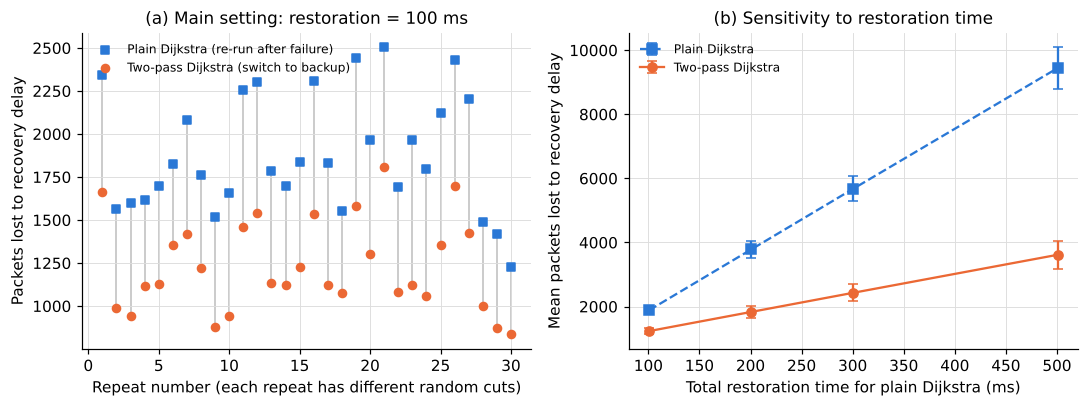

In [37]:
for CURRENT in ("print", "screen"):
    c = use_style(CURRENT)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
    x = np.arange(1, RUNS + 1)
    axes[0].vlines(x, sim_main.redundant_avoidable_lost, sim_main.single_avoidable_lost, color="#c8c8c8",
                   linewidth=1.2, zorder=1)
    axes[0].scatter(x, sim_main.single_avoidable_lost, marker="s", color=c["single"], s=28, zorder=2,
                    label="Plain Dijkstra (re-run after failure)")
    axes[0].scatter(x, sim_main.redundant_avoidable_lost, marker="o", color=c["redundant"], s=28, zorder=3,
                    label="Two-pass Dijkstra (switch to backup)")
    axes[0].set_xlabel("Repeat number (each repeat has different random cuts)")
    axes[0].set_ylabel("Packets lost to recovery delay")
    axes[0].set_title("(a) Main setting: restoration = 100 ms")
    axes[0].legend(fontsize=8)
    s = e6_sens
    axes[1].errorbar(s["restoration total (ms)"], s["plain Dijkstra avoidable lost"], yerr=s["plain CI"],
                     marker="s", linestyle="--", color=c["single"], label="Plain Dijkstra", capsize=3)
    axes[1].errorbar(s["restoration total (ms)"], s["two-pass avoidable lost"], yerr=s["two-pass CI"],
                     marker="o", color=c["redundant"], label="Two-pass Dijkstra", capsize=3)
    axes[1].set_xlabel("Total restoration time for plain Dijkstra (ms)")
    axes[1].set_ylabel("Mean packets lost to recovery delay")
    axes[1].set_title("(b) Sensitivity to restoration time")
    axes[1].legend(fontsize=8)
    fig.tight_layout()
    save(fig, "fig_simulation")
    if CURRENT == "print":
        plt.close(fig)
plt.show()

## 10. All key numbers in one place
This table is saved as `results/key_numbers.json`. The dissertation, the slides and the web app all use it.

In [38]:
e3n = e3_summary.set_index("network")
e5n = e5_summary.set_index("network")
key = {
    "versions": {"python": platform.python_version(), "networkx": nx.__version__, "numpy": np.__version__,
                 "pandas": pd.__version__, "matplotlib": matplotlib.__version__, "scipy": scipy.__version__},
    "machine": {"processor": platform.processor() or platform.machine(), "cores": os.cpu_count()},
    "topology": topo_table.to_dict(orient="records"),
    "e1": e1.to_dict(orient="records"),
    "e2": e2.to_dict(orient="records"),
    "e2_seeds_fully_separate_pct_min": float(e2_seeds["fully separate %"].min()),
    "e2_seeds_fully_separate_pct_max": float(e2_seeds["fully separate %"].max()),
    "e2_seeds_median_stretch_mean": float(e2_seeds["median stretch"].mean()),
    "e2_traps": traps.to_dict(orient="records"),
    "rules": rules.to_dict(orient="records"),
    "lagos_maiduguri": {k: example[k] for k in ("primary", "backup", "primary_cost", "backup_cost")},
    "abuja_example": {k: abuja_result[k] for k in ("primary", "backup", "primary_cost", "backup_cost")},
    "e3": e3_summary.to_dict(orient="records"),
    "e4": e4.to_dict(orient="records"),
    "e4_tests": e4_tests.to_dict(orient="records"),
    "e5": e5_summary.to_dict(orient="records"),
    "e5_scale": e5_scale.to_dict(orient="records"),
    "e5_prep": e5_prep.to_dict(orient="records"),
    "e6_settings": {"duration_s": DURATION_S, "rate_pps": RATE_PPS, "n_failures": N_FAILURES,
                    "repair_range_s": REPAIR_RANGE_S, "detect_s": DETECT_S, "compute_s": COMPUTE_S, "runs": RUNS},
    "e6_main": {k: {"mean": v[0], "ci": v[1]} for k, v in summary.items()},
    "e6_main_reduction_pct": float(reduction),
    "e6_main_fast_switch_share_pct": float(share_fast),
    "e6_main_wilcoxon_loss": {"W": float(w_loss.statistic), "p": float(w_loss.pvalue)},
    "e6_main_wilcoxon_pdr": {"W": float(w_pdr.statistic), "p": float(w_pdr.pvalue)},
    "e6_sensitivity": e6_sens.to_dict(orient="records"),
    "routing_table_build_ms": {"nigeria": t_ng * 1000, "ba50": t_ba * 1000},
}
with open("results/key_numbers.json", "w") as f:
    json.dump(key, f, indent=2, default=str)
print("Saved results/key_numbers.json")
pd.DataFrame([
    ["E1", "Our Dijkstra agrees with NetworkX", f"{e1['agreement %'].min()}% of pairs on all 4 networks"],
    ["E2", "Fully separate backup found (Nigeria-20)", f"{e2.iloc[0]['fully separate %']}% of 190 pairs"],
    ["E2", "Fully separate backup found (BA-50)", f"{e2.iloc[1]['fully separate %']}% of 1,225 pairs"],
    ["E2", "Median backup stretch (Nigeria-20 / BA-50)", f"{e2.iloc[0]['median stretch']} / {e2.iloc[1]['median stretch']}"],
    ["E3", "Single-link failures protected at once (Nigeria-20)", f"{e3n.loc['Nigeria-20', 'protected %']}%"],
    ["E3", "Single-link failures protected at once (BA-50)", f"{e3n.loc['BA-50', 'protected %']}%"],
    ["E5", "Median recovery compute: re-run vs switch (BA-50)",
     f"{e5n.loc['BA-50', 'restoration_median_ms']:.3f} ms vs {e5n.loc['BA-50', 'protection_median_ms']:.4f} ms"],
    ["E6", "Avoidable packet loss cut (restoration 100 ms)", f"{reduction:.1f}%"],
], columns=["Experiment", "Measure", "Result"])

Saved results/key_numbers.json


,Experiment,Measure,Result
0,E1,Our Dijkstra agrees with NetworkX,100.0% of pairs on all 4 networks
1,E2,Fully separate backup found (Nigeria-20),98.95% of 190 pairs
2,E2,Fully separate backup found (BA-50),"100.0% of 1,225 pairs"
3,E2,Median backup stretch (Nigeria-20 / BA-50),1.523 / 1.647
4,E3,Single-link failures protected at once (Nigeri...,99.65%
5,E3,Single-link failures protected at once (BA-50),100.0%
6,E5,Median recovery compute: re-run vs switch (BA-50),4.002 ms vs 0.0060 ms
7,E6,Avoidable packet loss cut (restoration 100 ms),34.5%


## 11. Check: the web app uses the same code
The file `redundant_dijkstra.py` holds exactly the functions defined above. The web app (`app.py`) imports it.
This cell loads that file and confirms it gives the same primary and backup paths for every Nigerian pair.

In [39]:
import importlib, sys
sys.path.insert(0, os.getcwd())
if not os.path.exists("redundant_dijkstra.py"):
    print("Upload redundant_dijkstra.py into the same folder to run this last check.")
else:
    import redundant_dijkstra as rdmod
    importlib.reload(rdmod)
    module_table = rdmod.build_routing_table(rdmod.nigeria_backbone())
    same = all(module_table[p]["primary"] == TABLE_NG[p]["primary"] and module_table[p]["backup"] == TABLE_NG[p]["backup"]
               for p in TABLE_NG)
    print("Module and notebook give identical paths for all", len(TABLE_NG), "pairs:", same)

Module and notebook give identical paths for all 190 pairs: True
